In [54]:
###  Problem Generator

import pickle
import numpy as np
from scipy.stats import truncnorm
from scipy.spatial.distance import cdist
import xgboost as xgb
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

np.random.seed(2026)

## Define median-based ensemble of surrogates
class medClassifier:
    def __init__(self, classifiers=None):
        self.classifiers = classifiers

    def predict(self, X):
        self.predictions_ = []
        for classifier in self.classifiers:
            try:
                self.predictions_.append(classifier.predict(X))
            except:
                X = xgb.DMatrix(X)
                self.predictions_.append(classifier.predict(X))
        med1 = np.median(self.predictions_, axis=0)
        mean1 = np.mean(self.predictions_, axis=0)
        # out = med1 + np.random.rand() * np.abs(med1 - mean1)
        out 
        return out

## main windfram problem generator
class WindFarmProblem:
    def __init__(self, ensemble_file="Ensemble.pkl",  # model used for obj1
                 rotor_diameter=126,                   
                 farm_length=333.33 * 5,
                 n_turbines=5,
                 nr_birds=1000,
                 bird_mean=-25000,
                 x_sigma=5,  # decide std and the bird group distribution
                 n_fields=5, # number of the oil/gas fileds
                 seed=2026): # random seed

        self.seed = seed
        self.rng_fields = np.random.default_rng(seed)
        self.rng_plot = np.random.default_rng(seed + 1)

        self.rotor_diameter = rotor_diameter
        self.farm_length = farm_length
        self.n_turbines = n_turbines
        self.nr_birds = nr_birds
        self.bird_mean = bird_mean
        self.x_sigma = x_sigma

        # It generates n fields when n_fields is an int or it generates using input list as coordinates
        self.fields = self._generate_oil_fields(n_fields)
        self.n_fields = len(self.fields)

        with open(ensemble_file, "rb") as file:
            self.ensemble = pickle.load(file)

    ## turn [x1, x2,...y1, y2...] into [[x1,y1], [x2, y2]]
    def _to_coords(self, x):   
        x = np.asarray(x, dtype=float)
        xs = x[:self.n_turbines]
        ys = x[self.n_turbines:]
        coords = np.column_stack((xs, ys))
        return coords

    ##  fields generation using coordinates list
    def _validate_field_list(self, field_list): 
        """
        field_list format:
        [
            (xmin, xmax, ymin, ymax),
            ...
        ]
        """
        if len(field_list) > 5:
            raise ValueError("At most 5 oil fields are allowed.")

        validated = []
        for i, field in enumerate(field_list):
            if len(field) != 4:
                raise ValueError(f"Field {i} must have 4 values: (xmin, xmax, ymin, ymax).")

            xmin, xmax, ymin, ymax = map(float, field)

            if not (0 <= xmin < xmax <= 1):
                raise ValueError(
                    f"Field {i} has invalid x-range: require 0 <= xmin < xmax <= 1, got {(xmin, xmax)}"
                )
            if not (0 <= ymin < ymax <= 1):
                raise ValueError(
                    f"Field {i} has invalid y-range: require 0 <= ymin < ymax <= 1, got {(ymin, ymax)}"
                )

            validated.append((xmin, xmax, ymin, ymax))

        return validated

    ## generate random oil fields OR use provided oil field list
    def _generate_oil_fields(self, n_fields):
        # case 1: n_fields is an integer -> random generation
        if isinstance(n_fields, int):
            fields = []
            n_fields = min(n_fields, 5)

            for _ in range(n_fields):
                width = self.rng_fields.uniform(0.05, 0.5)
                height = self.rng_fields.uniform(0.05, 0.5)

                xmin = self.rng_fields.uniform(0, 1 - width)
                ymin = self.rng_fields.uniform(0, 1 - height)

                xmax = xmin + width
                ymax = ymin + height

                fields.append((xmin, xmax, ymin, ymax))

            return fields

        # case 2: n_fields is a list/tuple/ndarray of coordinates
        elif isinstance(n_fields, (list, tuple, np.ndarray)):
            return self._validate_field_list(list(n_fields))

        else:
            raise TypeError(
                "n_fields must be either an int or a list of field coordinates "
                "[(xmin, xmax, ymin, ymax), ...]"
            )

    ## using ensemble model to predict the obj1
    def objective1(self, x): 
        x = np.array([x])
        pred = self.ensemble.predict(x)
        return pred[0]

    ## calculaate the percentage of birds are too close
    def objective2(self, x): 
        x = np.array([x])
        coords = np.resize(x, (2, self.n_turbines))

        bird_std = 25000 / self.x_sigma
        birds = truncnorm.rvs(
            self.x_sigma,
            self.x_sigma + self.farm_length / bird_std,
            loc=self.bird_mean,
            scale=bird_std,
            size=self.nr_birds,
            random_state=2026
        )

        leftmost = np.min(coords[0]) * self.farm_length
        threshold = leftmost - self.rotor_diameter
        close_birds = np.sum(birds >= threshold) / self.nr_birds
        return close_birds

    ## calculate the total length of cables connecting turbos
    def objective3(self, x, order): 
        coords = self._to_coords(x)

        turbine_order = order[:-1]
        hub = np.array(order[-1], dtype=float)

        total_length = 0.0
        current_point = hub

        for turb_id in turbine_order:
            turb_coord = coords[turb_id - 1]
            total_length += np.linalg.norm(turb_coord - current_point)
            current_point = turb_coord

        return total_length * self.farm_length
        
    ## Constraint1 is that the distances between two turbos should be bigger than 2 * self.rotor_diameter
    ## cv is the constaint1 violation;
    def constraint1(self, x):  
        coords = self._to_coords(x)

        min_dist = np.inf
        for turb in range(self.n_turbines - 1):
            dists = cdist([coords[turb]], coords[turb + 1:])
            next_min = np.min(dists)
            if next_min < min_dist:
                min_dist = next_min

        cv = 2 * self.rotor_diameter - min_dist * self.farm_length
        return cv

    ## constraint2 is that the turbo should not locate in a gas/oil filed; n_inside is the constaint1 violation
    def constraint2(self, x):
        coords = self._to_coords(x)
        n_inside = 0

        for xi, yi in coords:
            for xmin, xmax, ymin, ymax in self.fields:
                if xmin <= xi <= xmax and ymin <= yi <= ymax:
                    n_inside += 1
                    break

        return n_inside

        
    ## evaluate all the objs and cons
    def evaluate(self, x, order):
        return {
            "f1": self.objective1(x),
            "f2": self.objective2(x),
            "f3": self.objective3(x, order),
            "g1": self.constraint1(x),
            "g2": self.constraint2(x)
        }

    ## plot the problem and the solution
    def plot_layout(self, x, order):
        coords = self._to_coords(x)

        turbine_order = order[:-1]
        hub = np.array(order[-1], dtype=float)

        fig, ax = plt.subplots(figsize=(7, 7))

        # 1x1 windfarm area
        farm_rect = Rectangle((0, 0), 1, 1, fill=False, edgecolor='blue', linewidth=2)
        ax.add_patch(farm_rect)

        # gas/oil fields
        for i, (xmin, xmax, ymin, ymax) in enumerate(self.fields, start=1):
            rect = Rectangle(
                (xmin, ymin),
                xmax - xmin,
                ymax - ymin,
                facecolor='orange',
                edgecolor='red',
                alpha=0.35
            )
            ax.add_patch(rect)

            ax.text(
                (xmin + xmax) / 2,
                (ymin + ymax) / 2,
                f'field{i}',
                ha='center',
                va='center',
                fontsize=9
            )

        # turbos
        ax.scatter(coords[:, 0], coords[:, 1], s=80, marker='o', label='Turbines')
        for i, (tx, ty) in enumerate(coords, start=1):
            ax.text(tx + 0.015, ty + 0.015, f'T{i}', fontsize=10)

        # hub
        ax.scatter(hub[0], hub[1], s=120, marker='s', label='Hub')
        ax.text(hub[0] + 0.015, hub[1] + 0.015, 'Hub', fontsize=10)

        # cables
        route_points = [hub]
        for turb_id in turbine_order:
            route_points.append(coords[turb_id - 1])

        route_points = np.array(route_points)
        ax.plot(route_points[:, 0], route_points[:, 1], '-o', linewidth=1.5)

        # birds group
        bird_std = 25000 / self.x_sigma
        birds_m = truncnorm.rvs(
            self.x_sigma,
            self.x_sigma + self.farm_length / bird_std,
            loc=self.bird_mean,
            scale=bird_std,
            size=300,
            random_state=2026
        )

        birds_x = birds_m / self.farm_length
        birds_y = self.rng_plot.uniform(0, 1, size=len(birds_x))

        ax.scatter(birds_x, birds_y, s=10, alpha=0.3, label='Birds')

        ax.set_xlim(0, 1.6)
        ax.set_ylim(0, 1.6)

        ax.set_aspect('equal')
        ax.set_title('Wind Farm Layout')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.show()

In [58]:
###  Generate a new problem
problem = WindFarmProblem(
                         # ensemble_file="Ensemble.pkl",
                         ensemble_file=r"version_2\Ensemble.pkl",
                         rotor_diameter=126,
                         farm_length=333.33*5,
                         n_turbines=5,
                         nr_birds=1000,
                         bird_mean=-25000,
                         x_sigma=12,
                         n_fields=[(0.10, 0.30, 0.17, 0.40),
                                   (0.50, 0.80, 0.01, 0.20),
                                   (0.60, 0.90, 0.60, 0.85),],
                         )

{'f1': -33.852695, 'f2': 0.13, 'f3': 3330.7538821678863, 'g1': 183.28226009064338, 'g2': 2}


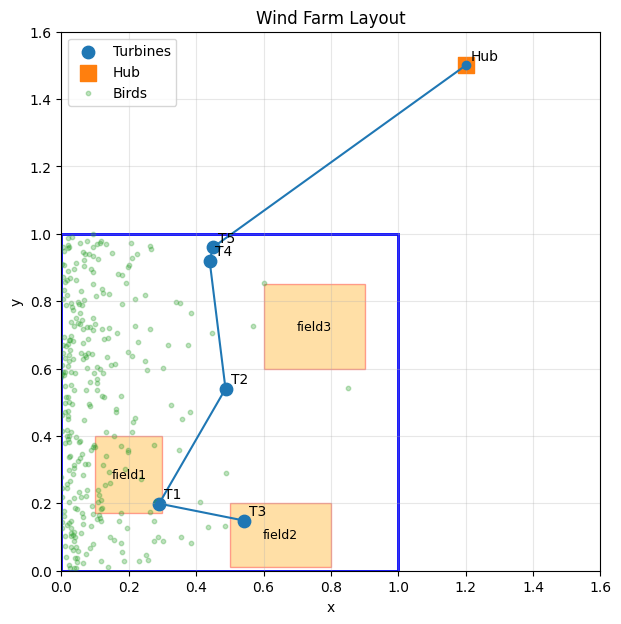

In [59]:
###  give the input(coordinates of turbos and the hub, and the order of cable conneting) 
###  and get the results(objectives and constraints) and plot
order = [5, 4,2,1,3,[1.2, 1.5]]

x3 = [0.29, 0.4871309875290023, 0.54153605985017246, 0.44, 0.45, 
      0.1992480932223422, 0.5400992985215289, 0.14902261675540462, 0.92, 0.96]

print(problem.evaluate(x3, order))
problem.plot_layout(x3, order)